# PTB-XL: MI vs Non-MI — Control vs Gaussian Noise

This Colab notebook compares the same 1D CNN under two conditions:

- **Control:** no augmentation
- **Treatment:** Gaussian noise (`σ = 0.02`) added **only to training inputs**

It uses a fixed 5,000-record subset drawn from the official patient-separated `strat_fold` split: folds 1–8 for training (4,000), fold 9 for validation (500), and fold 10 for testing (500). Each split is balanced MI/Non-MI when the available records permit it. Both conditions run with seeds 42, 123, and 456.

**Important caveat:** this deliberately balanced subset does not represent PTB-XL's natural disease prevalence. Report its metrics as controlled experimental results, not as expected clinical performance. `Non-MI` means a diagnostic ECG without an MI diagnostic superclass; it does **not** mean healthy/normal.


## 1. Mount Drive and install dependencies

For best speed, select a GPU runtime in Colab before running all cells. The data is expected at `/content/drive/MyDrive/datasets/ptb-xl`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%pip install -q wfdb captum seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 32.7 MB/s eta 0:00:00


## 2. Imports and experiment configuration

All outputs, including the sampled metadata, checkpoints, training histories, metrics, and figures, are saved to Drive.


In [3]:
import ast
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import wfdb
from captum.attr import IntegratedGradients
from matplotlib.collections import LineCollection
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

DATA_DIR = Path('/content/drive/MyDrive/datasets/ptb-xl')
OUTPUT_DIR = Path('/content/drive/MyDrive/ptbxl_experiment_5000')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_SEED = 2026
RUN_SEEDS = [42, 123, 456]
TARGET_SIZES = {'train': 4000, 'validation': 500, 'test': 500}
NOISE_STD = 0.02
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3
PATIENCE = 5
NUM_WORKERS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

required = [DATA_DIR / 'ptbxl_database.csv', DATA_DIR / 'scp_statements.csv']
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing required files: {missing}')

print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('Warning: training six models on CPU may take a while.')
print('Output directory:', OUTPUT_DIR)


Device: cuda
GPU: Tesla T4
Output directory: /content/drive/MyDrive/ptbxl_experiment_5000


## 3. Load metadata and define MI vs Non-MI correctly

A record is **MI** if at least one of its diagnostic SCP codes maps to PTB-XL diagnostic superclass `MI`. A record is **Non-MI** if it has at least one recognized diagnostic code but none maps to `MI`. Records without any diagnostic superclass are excluded rather than silently treated as negatives.


In [4]:
meta = pd.read_csv(DATA_DIR / 'ptbxl_database.csv', index_col='ecg_id')
scp = pd.read_csv(DATA_DIR / 'scp_statements.csv', index_col=0)
meta['scp_codes'] = meta['scp_codes'].apply(ast.literal_eval)

diagnostic_rows = scp[
    (pd.to_numeric(scp['diagnostic'], errors='coerce').fillna(0) == 1)
    & scp['diagnostic_class'].notna()
]
diagnostic_codes = set(diagnostic_rows.index.astype(str))
mi_codes = set(
    diagnostic_rows.loc[diagnostic_rows['diagnostic_class'].eq('MI')]
    .index.astype(str)
)

def diagnostic_label(code_dict):
    present = set(map(str, code_dict.keys()))
    recognized = present & diagnostic_codes
    if not recognized:
        return pd.Series({'has_diagnostic': False, 'label': pd.NA})
    return pd.Series({
        'has_diagnostic': True,
        'label': int(bool(present & mi_codes)),
    })

meta[['has_diagnostic', 'label']] = meta['scp_codes'].apply(diagnostic_label)
eligible = meta.loc[meta['has_diagnostic'].eq(True)].copy()
eligible['label'] = eligible['label'].astype(np.int64)

print(f'Total metadata records: {len(meta):,}')
print(f'Eligible diagnostic records: {len(eligible):,}')
print('\nClass counts among eligible records:')
display(eligible['label'].value_counts().rename(index={0: 'Non-MI', 1: 'MI'}))


Total metadata records: 21,799
Eligible diagnostic records: 21,388

Class counts among eligible records:


,count
label,
Non-MI,15919
MI,5469


## 4. Select the fixed 5,000-record subset using official folds

Sampling is deterministic and independent of the three training seeds. The helper first attempts a 50/50 class split. If a fold lacks enough examples from one class, it uses every available minority example and fills the remainder from the other class while printing the achieved counts.


In [5]:
def balanced_sample(frame, n, seed, split_name):
    if len(frame) < n:
        raise ValueError(f'{split_name}: only {len(frame)} eligible records; need {n}.')

    by_class = {label: frame.loc[frame['label'].eq(label)] for label in (0, 1)}
    take = {0: min(n // 2, len(by_class[0])), 1: min(n // 2, len(by_class[1]))}
    remaining = n - take[0] - take[1]
    for label in sorted((0, 1), key=lambda value: len(by_class[value]) - take[value], reverse=True):
        extra = min(remaining, len(by_class[label]) - take[label])
        take[label] += extra
        remaining -= extra
    if remaining:
        raise ValueError(f'{split_name}: unable to sample {n} records.')

    parts = [
        by_class[label].sample(n=take[label], random_state=seed + label)
        for label in (0, 1)
    ]
    sampled = pd.concat(parts).sample(frac=1, random_state=seed + 10).copy()
    sampled['split'] = split_name
    print(f'{split_name:10s}: total={len(sampled):4d}, Non-MI={take[0]:4d}, MI={take[1]:4d}')
    return sampled

train_meta = balanced_sample(
    eligible.loc[eligible['strat_fold'].between(1, 8)],
    TARGET_SIZES['train'], SAMPLE_SEED, 'train'
)
val_meta = balanced_sample(
    eligible.loc[eligible['strat_fold'].eq(9)],
    TARGET_SIZES['validation'], SAMPLE_SEED + 100, 'validation'
)
test_meta = balanced_sample(
    eligible.loc[eligible['strat_fold'].eq(10)],
    TARGET_SIZES['test'], SAMPLE_SEED + 200, 'test'
)

selected_meta = pd.concat([train_meta, val_meta, test_meta])
assert len(selected_meta) == 5000
assert selected_meta.index.is_unique
assert set(train_meta['strat_fold']).issubset(set(range(1, 9)))
assert set(val_meta['strat_fold']) == {9}
assert set(test_meta['strat_fold']) == {10}

# PTB-XL folds are patient-separated; verify this property in the selected subset.
if 'patient_id' in selected_meta.columns:
    patient_sets = {
        split: set(group['patient_id'].dropna())
        for split, group in selected_meta.groupby('split')
    }
    assert patient_sets['train'].isdisjoint(patient_sets['validation'])
    assert patient_sets['train'].isdisjoint(patient_sets['test'])
    assert patient_sets['validation'].isdisjoint(patient_sets['test'])

selected_meta.to_csv(OUTPUT_DIR / 'subset_metadata_5000.csv')
display(pd.crosstab(selected_meta['split'], selected_meta['label']).rename(columns={0: 'Non-MI', 1: 'MI'}))
print('Saved:', OUTPUT_DIR / 'subset_metadata_5000.csv')


train     : total=4000, Non-MI=2000, MI=2000
validation: total= 500, Non-MI= 250, MI= 250
test      : total= 500, Non-MI= 250, MI= 250


label,Non-MI,MI
split,,
test,250,250
train,2000,2000
validation,250,250


Saved: /content/drive/MyDrive/ptbxl_experiment_5000/subset_metadata_5000.csv


## 5. Load only the selected 100 Hz waveforms

`filename_lr` points to the 100 Hz, 10-second recordings (`12 × 1,000` after transposition). Each lead is z-normalized within its own record. The entire selected subset is loaded once into RAM so all six runs use exactly the same inputs.


In [6]:
signals = []
lead_names = None
expected_shape = None

for ecg_id, row in tqdm(selected_meta.iterrows(), total=len(selected_meta), desc='Loading selected ECGs'):
    record_path = DATA_DIR / row['filename_lr']
    if not record_path.with_suffix('.hea').exists() or not record_path.with_suffix('.dat').exists():
        raise FileNotFoundError(f'Waveform files missing for ECG {ecg_id}: {record_path}')

    signal, fields = wfdb.rdsamp(str(record_path))  # [time, leads]
    signal = signal.astype(np.float32).T           # [leads, time]
    if expected_shape is None:
        expected_shape = signal.shape
        lead_names = list(fields['sig_name'])
    if signal.shape != expected_shape:
        raise ValueError(f'Unexpected shape for ECG {ecg_id}: {signal.shape}, expected {expected_shape}')

    mean = signal.mean(axis=1, keepdims=True)
    std = signal.std(axis=1, keepdims=True)
    signal = (signal - mean) / np.maximum(std, 1e-6)
    signals.append(signal)

X = np.stack(signals).astype(np.float32)
y = selected_meta['label'].to_numpy(dtype=np.float32)
split_names = selected_meta['split'].to_numpy()
ecg_ids = selected_meta.index.to_numpy()

assert X.shape == (5000, 12, 1000), X.shape
assert np.isfinite(X).all()
indices = {
    split: np.flatnonzero(split_names == split)
    for split in ('train', 'validation', 'test')
}
print('X shape:', X.shape, '| RAM:', f'{X.nbytes / 1024**2:.1f} MB')
print('Leads:', lead_names)
print({name: len(idx) for name, idx in indices.items()})


Loading selected ECGs:   0%|          | 0/5000 [00:00<?, ?it/s]

X shape: (5000, 12, 1000) | RAM: 228.9 MB
Leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
{'train': 4000, 'validation': 500, 'test': 500}


## 6. Dataset, model, and evaluation utilities

Noise is sampled afresh whenever a training example is read in the Treatment condition. Validation and test examples are never augmented. The decision threshold is selected on the validation set by maximizing F1, then frozen for the test set; ROC-AUC and Average Precision remain threshold-free.


In [7]:
class ECGDataset(Dataset):
    def __init__(self, X, y, indices, augment=False, noise_std=0.02):
        self.X = X
        self.y = y
        self.indices = np.asarray(indices)
        self.augment = augment
        self.noise_std = noise_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = self.indices[item]
        x = torch.from_numpy(self.X[idx])
        target = torch.tensor(self.y[idx], dtype=torch.float32)
        if self.augment:
            x = x + torch.randn_like(x) * self.noise_std
        return x, target


class ECGCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(12, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(128, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).squeeze(-1)
        return self.classifier(x).squeeze(-1)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_loader(dataset, batch_size, shuffle, seed):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=NUM_WORKERS > 0,
        generator=generator,
    )


@torch.no_grad()
def predict(model, loader):
    model.eval()
    probs, labels = [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE, non_blocking=True))
        probs.append(torch.sigmoid(logits).cpu().numpy())
        labels.append(yb.numpy())
    return np.concatenate(labels).astype(int), np.concatenate(probs)


def best_f1_threshold(labels, probs):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = np.array([f1_score(labels, probs >= threshold) for threshold in thresholds])
    return float(thresholds[scores.argmax()])


def metric_dict(labels, probs, threshold):
    predictions = (probs >= threshold).astype(int)
    return {
        'roc_auc': roc_auc_score(labels, probs),
        'average_precision': average_precision_score(labels, probs),
        'f1': f1_score(labels, predictions),
        'accuracy': accuracy_score(labels, predictions),
    }


model_preview = ECGCNN()
print(model_preview)
print(f'Parameters: {sum(p.numel() for p in model_preview.parameters()):,}')


ECGCNN(
  (features): Sequential(
    (0): Conv1d(12, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)
Parameters: 38,305


## 7. Train Control and Treatment across three seeds

For every seed, the two conditions share the architecture, initialization seed, data subset, batch order seed, optimizer, and training settings. The only intended difference is Gaussian noise in the Treatment training loader. The checkpoint with the highest validation ROC-AUC is retained for each run, with early stopping to avoid unnecessary epochs.


In [10]:
def run_experiment(condition, seed):
    augment = condition == 'Treatment'
    seed_everything(seed)

    train_ds = ECGDataset(
        X, y, indices['train'],
        augment=augment,
        noise_std=NOISE_STD
    )
    val_ds = ECGDataset(
        X, y, indices['validation'],
        augment=False
    )
    test_ds = ECGDataset(
        X, y, indices['test'],
        augment=False
    )

    train_loader = make_loader(
        train_ds, BATCH_SIZE, True, seed
    )
    val_loader = make_loader(
        val_ds, BATCH_SIZE * 2, False, seed
    )
    test_loader = make_loader(
        test_ds, BATCH_SIZE * 2, False, seed
    )

    model = ECGCNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    checkpoint_path = (
        CHECKPOINT_DIR /
        f'{condition.lower()}_seed_{seed}.pt'
    )

    best_val_auc = -np.inf
    stale_epochs = 0
    history = []
    start = time.time()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(xb)
            seen += len(xb)

        val_labels, val_probs = predict(
            model,
            val_loader
        )

        val_metrics = metric_dict(
            val_labels,
            val_probs,
            threshold=0.5
        )

        row = {
            'condition': condition,
            'seed': seed,
            'epoch': epoch,
            'train_loss': running_loss / seen,
            **{
                f'val_{key}': value
                for key, value in val_metrics.items()
            },
        }

        history.append(row)

        print(
            f'{condition:9s} seed={seed} '
            f'epoch={epoch:02d} '
            f'loss={row["train_loss"]:.4f} '
            f'val_auc={row["val_roc_auc"]:.4f}'
        )

        if row['val_roc_auc'] > best_val_auc + 1e-6:
            best_val_auc = row['val_roc_auc']
            stale_epochs = 0

            torch.save(
                {
                    'model_state_dict': model.state_dict(),
                    'condition': condition,
                    'seed': int(seed),
                    'epoch': int(epoch),
                    'best_val_auc': float(best_val_auc),
                    'noise_std': float(
                        NOISE_STD if augment else 0.0
                    ),
                    'lead_names': list(lead_names),
                },
                checkpoint_path
            )

        else:
            stale_epochs += 1

            if stale_epochs >= PATIENCE:
                print(f'Early stopping at epoch {epoch}.')
                break

    # Safe here because this checkpoint was created
    # by this notebook.
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    val_labels, val_probs = predict(
        model,
        val_loader
    )

    threshold = best_f1_threshold(
        val_labels,
        val_probs
    )

    test_labels, test_probs = predict(
        model,
        test_loader
    )

    metrics = metric_dict(
        test_labels,
        test_probs,
        threshold
    )

    result = {
        'condition': condition,
        'seed': seed,
        'best_epoch': checkpoint['epoch'],
        'best_val_auc': checkpoint['best_val_auc'],
        'validation_threshold': threshold,
        **metrics,
        'runtime_minutes': (time.time() - start) / 60,
        'checkpoint': str(checkpoint_path),
    }

    return result, history


all_results = []
all_history = []

for seed in RUN_SEEDS:
    for condition in ('Control', 'Treatment'):
        result, history = run_experiment(
            condition,
            seed
        )

        all_results.append(result)
        all_history.extend(history)

        pd.DataFrame(all_results).to_csv(
            OUTPUT_DIR / 'results_by_seed.csv',
            index=False
        )

        pd.DataFrame(all_history).to_csv(
            OUTPUT_DIR / 'training_history.csv',
            index=False
        )

        print(
            'Test:',
            {
                key: round(result[key], 4)
                for key in (
                    'roc_auc',
                    'average_precision',
                    'f1',
                    'accuracy'
                )
            }
        )

results_df = pd.DataFrame(all_results)
history_df = pd.DataFrame(all_history)

display(results_df)
print('Saved checkpoints and CSV files to:', OUTPUT_DIR)

Control   seed=42 epoch=01 loss=0.5253 val_auc=0.8632
Control   seed=42 epoch=02 loss=0.4320 val_auc=0.8887
Control   seed=42 epoch=03 loss=0.4009 val_auc=0.8903
Control   seed=42 epoch=04 loss=0.3847 val_auc=0.8925
Control   seed=42 epoch=05 loss=0.3644 val_auc=0.8894
Control   seed=42 epoch=06 loss=0.3532 val_auc=0.9067
Control   seed=42 epoch=07 loss=0.3385 val_auc=0.8900
Control   seed=42 epoch=08 loss=0.3303 val_auc=0.9049
Control   seed=42 epoch=09 loss=0.3186 val_auc=0.9118
Control   seed=42 epoch=10 loss=0.3098 val_auc=0.9045
Control   seed=42 epoch=11 loss=0.3005 val_auc=0.8901
Control   seed=42 epoch=12 loss=0.2850 val_auc=0.8919
Control   seed=42 epoch=13 loss=0.2819 val_auc=0.9072
Control   seed=42 epoch=14 loss=0.2637 val_auc=0.9088
Early stopping at epoch 14.
Test: {'roc_auc': np.float64(0.91), 'average_precision': np.float64(0.912), 'f1': 0.8235, 'accuracy': 0.826}
Treatment seed=42 epoch=01 loss=0.5253 val_auc=0.8631
Treatment seed=42 epoch=02 loss=0.4321 val_auc=0.8886

,condition,seed,best_epoch,best_val_auc,validation_threshold,roc_auc,average_precision,f1,accuracy,runtime_minutes,checkpoint
0,Control,42,9,0.911776,0.560,0.910048,0.912009,0.823529,0.826,0.201972,/content/drive/MyDrive/ptbxl_experiment_5000/c...
1,Treatment,42,9,0.912112,0.650,0.910928,0.912567,0.820084,0.828,0.720449,/content/drive/MyDrive/ptbxl_experiment_5000/c...
2,Control,123,11,0.910512,0.850,0.911856,0.915970,0.843931,0.838,0.124318,/content/drive/MyDrive/ptbxl_experiment_5000/c...
3,Treatment,123,11,0.910064,0.855,0.912560,0.916922,0.843931,0.838,0.814975,/content/drive/MyDrive/ptbxl_experiment_5000/c...
4,Control,456,11,0.907664,0.375,0.916832,0.922014,0.833013,0.826,0.133715,/content/drive/MyDrive/ptbxl_experiment_5000/c...
5,Treatment,456,11,0.907616,0.330,0.916144,0.921373,0.835878,0.828,0.702225,/content/drive/MyDrive/ptbxl_experiment_5000/c...


Saved checkpoints and CSV files to: /content/drive/MyDrive/ptbxl_experiment_5000


## 8. Summarize mean ± standard deviation and plot comparisons

Standard deviations use the three seed-level test results (`ddof=1`). With only three seeds, treat uncertainty estimates as descriptive rather than definitive. A paired comparison is appropriate because each Control seed has a matching Treatment seed.


In [11]:
METRICS = ['roc_auc', 'average_precision', 'f1', 'accuracy']
summary_rows = []
for condition, group in results_df.groupby('condition', sort=False):
    for metric in METRICS:
        mean = group[metric].mean()
        std = group[metric].std(ddof=1)
        summary_rows.append({
            'condition': condition,
            'metric': metric,
            'mean': mean,
            'std': std,
            'mean_plus_minus_std': f'{mean:.4f} ± {std:.4f}',
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / 'summary_mean_std.csv', index=False)
display(summary_df.pivot(index='metric', columns='condition', values='mean_plus_minus_std'))

paired = results_df.pivot(index='seed', columns='condition', values=METRICS)
deltas = pd.DataFrame({
    metric: paired[(metric, 'Treatment')] - paired[(metric, 'Control')]
    for metric in METRICS
})
deltas.index.name = 'seed'
deltas.to_csv(OUTPUT_DIR / 'paired_treatment_minus_control.csv')
print('Treatment − Control for each matched seed:')
display(deltas)


condition,Control,Treatment
metric,,
accuracy,0.8300 ± 0.0069,0.8313 ± 0.0058
average_precision,0.9167 ± 0.0050,0.9170 ± 0.0044
f1,0.8335 ± 0.0102,0.8333 ± 0.0121
roc_auc,0.9129 ± 0.0035,0.9132 ± 0.0027


Treatment − Control for each matched seed:


,roc_auc,average_precision,f1,accuracy
seed,,,,
42,0.000880,0.000558,-0.003446,0.002
123,0.000704,0.000952,0.000000,0.000
456,-0.000688,-0.000641,0.002864,0.002


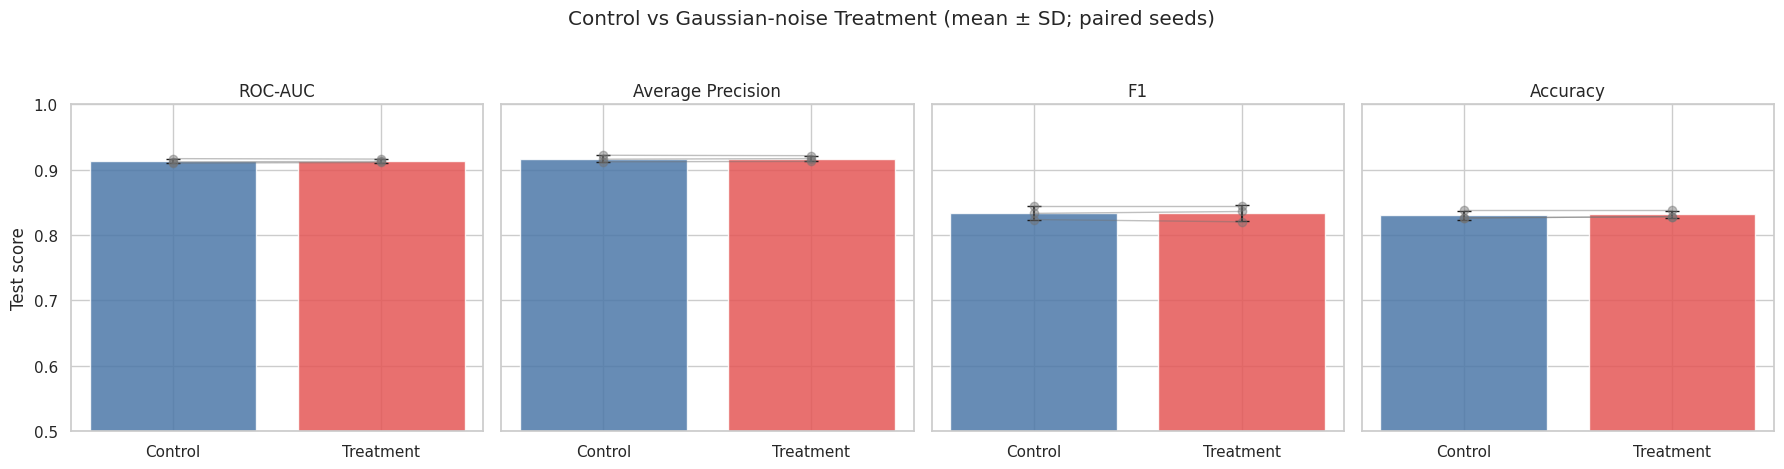

Saved: /content/drive/MyDrive/ptbxl_experiment_5000/condition_comparison.png


In [12]:
sns.set_theme(style='whitegrid')
pretty = {
    'roc_auc': 'ROC-AUC',
    'average_precision': 'Average Precision',
    'f1': 'F1',
    'accuracy': 'Accuracy',
}
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
colors = {'Control': '#4C78A8', 'Treatment': '#E45756'}

for ax, metric in zip(axes, METRICS):
    stats = summary_df.loc[summary_df['metric'].eq(metric)].set_index('condition')
    order = ['Control', 'Treatment']
    means = stats.loc[order, 'mean'].to_numpy()
    stds = stats.loc[order, 'std'].to_numpy()
    ax.bar(order, means, yerr=stds, capsize=5, color=[colors[name] for name in order], alpha=0.85)
    for seed in RUN_SEEDS:
        pair = results_df.loc[results_df['seed'].eq(seed)].set_index('condition')
        values = pair.loc[order, metric].to_numpy()
        ax.plot(order, values, color='0.45', alpha=0.45, marker='o', linewidth=1)
    ax.set_title(pretty[metric])
    ax.set_ylim(0.5, 1.0)
    ax.set_xlabel('')
axes[0].set_ylabel('Test score')
fig.suptitle('Control vs Gaussian-noise Treatment (mean ± SD; paired seeds)', y=1.04)
fig.tight_layout()
comparison_path = OUTPUT_DIR / 'condition_comparison.png'
fig.savefig(comparison_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', comparison_path)


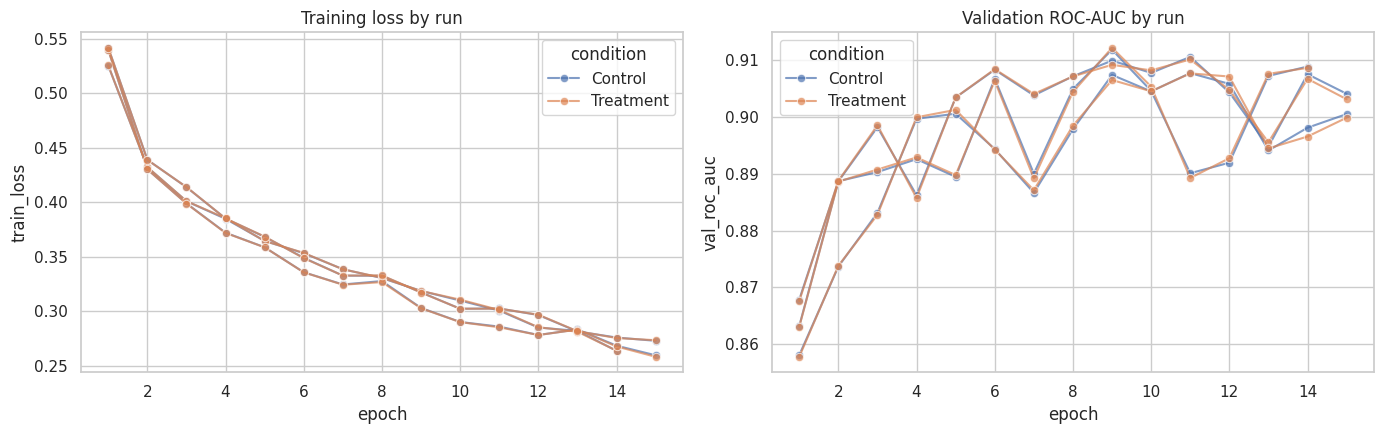

Saved: /content/drive/MyDrive/ptbxl_experiment_5000/training_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(
    data=history_df, x='epoch', y='train_loss', hue='condition',
    units='seed', estimator=None, alpha=0.7, marker='o', ax=axes[0]
)
axes[0].set_title('Training loss by run')
sns.lineplot(
    data=history_df, x='epoch', y='val_roc_auc', hue='condition',
    units='seed', estimator=None, alpha=0.7, marker='o', ax=axes[1]
)
axes[1].set_title('Validation ROC-AUC by run')
fig.tight_layout()
history_plot_path = OUTPUT_DIR / 'training_curves.png'
fig.savefig(history_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', history_plot_path)


## 9. Integrated Gradients on the best Treatment model

The best Treatment model is selected by **validation ROC-AUC**, not test performance. For an interpretable positive example, the notebook displays the true-MI test record with the highest predicted MI probability. The zero tensor is the baseline in normalized input space (the per-lead mean).

These attributions explain this model prediction; they are not proof of clinical causality. The lead summary below is a **local** explanation for one ECG, not a population-level ranking.


In [14]:
treatment_runs = results_df.loc[results_df['condition'].eq('Treatment')]
best_run = treatment_runs.loc[treatment_runs['best_val_auc'].idxmax()]
best_seed = int(best_run['seed'])
best_checkpoint_path = Path(best_run['checkpoint'])

checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
best_model = ECGCNN().to(DEVICE)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

test_ds = ECGDataset(X, y, indices['test'], augment=False)
test_loader = make_loader(test_ds, BATCH_SIZE * 2, False, best_seed)
test_labels, test_probs = predict(best_model, test_loader)
positive_positions = np.flatnonzero(test_labels == 1)
if len(positive_positions) == 0:
    raise RuntimeError('No MI test examples are available for Integrated Gradients.')
local_test_position = positive_positions[np.argmax(test_probs[positive_positions])]
global_index = indices['test'][local_test_position]

input_tensor = torch.from_numpy(X[global_index:global_index + 1]).to(DEVICE)
baseline = torch.zeros_like(input_tensor)
ig = IntegratedGradients(best_model)
attributions, convergence_delta = ig.attribute(
    input_tensor,
    baselines=baseline,
    n_steps=64,
    method='gausslegendre',
    internal_batch_size=16,
    return_convergence_delta=True,
)
attr = attributions.squeeze(0).detach().cpu().numpy()
signal = input_tensor.squeeze(0).detach().cpu().numpy()
probability = float(torch.sigmoid(best_model(input_tensor)).item())
delta = float(convergence_delta.detach().cpu().item())

lead_importance_raw = np.mean(np.abs(attr), axis=1)
lead_importance = lead_importance_raw / lead_importance_raw.sum()
lead_df = pd.DataFrame({'lead': lead_names, 'relative_importance': lead_importance})
lead_df = lead_df.sort_values('relative_importance', ascending=False).reset_index(drop=True)
lead_df.to_csv(OUTPUT_DIR / 'integrated_gradients_lead_importance.csv', index=False)

print('Best Treatment seed:', best_seed)
print('Checkpoint selected by validation AUC:', f'{checkpoint["best_val_auc"]:.4f}')
print('ECG ID:', ecg_ids[global_index])
print('True label: MI')
print('Predicted P(MI):', f'{probability:.4f}')
print('Integrated Gradients convergence delta:', f'{delta:.6f}')
display(lead_df)


Best Treatment seed: 42
Checkpoint selected by validation AUC: 0.9121
ECG ID: 15647
True label: MI
Predicted P(MI): 0.9999
Integrated Gradients convergence delta: -0.001882


,lead,relative_importance
0,I,0.122627
1,AVR,0.111030
2,AVF,0.108257
3,V2,0.089576
4,V4,0.087803
5,II,0.086197
6,V6,0.078432
7,III,0.071502
8,AVL,0.066652
9,V5,0.064989


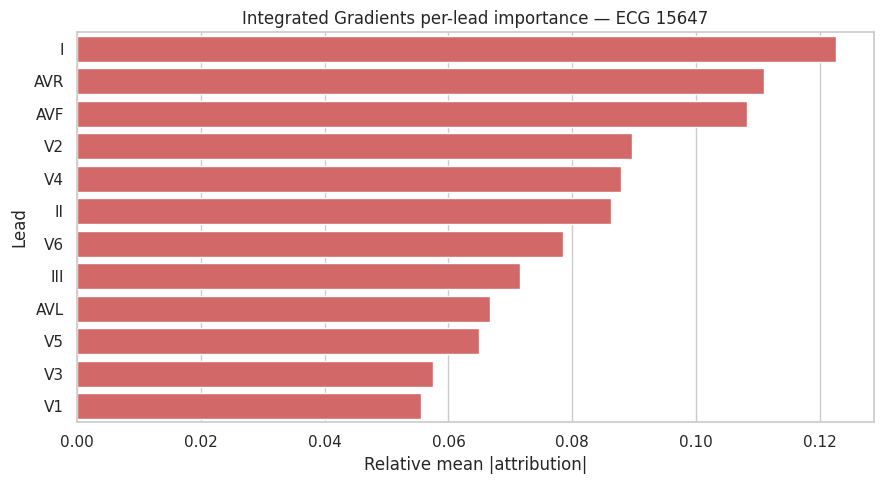

Saved: /content/drive/MyDrive/ptbxl_experiment_5000/integrated_gradients_lead_importance.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=lead_df, x='relative_importance', y='lead', color='#E45756', ax=ax)
ax.set_title(f'Integrated Gradients per-lead importance — ECG {ecg_ids[global_index]}')
ax.set_xlabel('Relative mean |attribution|')
ax.set_ylabel('Lead')
fig.tight_layout()
lead_plot_path = OUTPUT_DIR / 'integrated_gradients_lead_importance.png'
fig.savefig(lead_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', lead_plot_path)


### ECG waveform attribution map

Red waveform segments push the model output toward MI; blue segments push it toward Non-MI. Color intensity is normalized across this single record for visualization, so it shows relative—not absolute—strength.


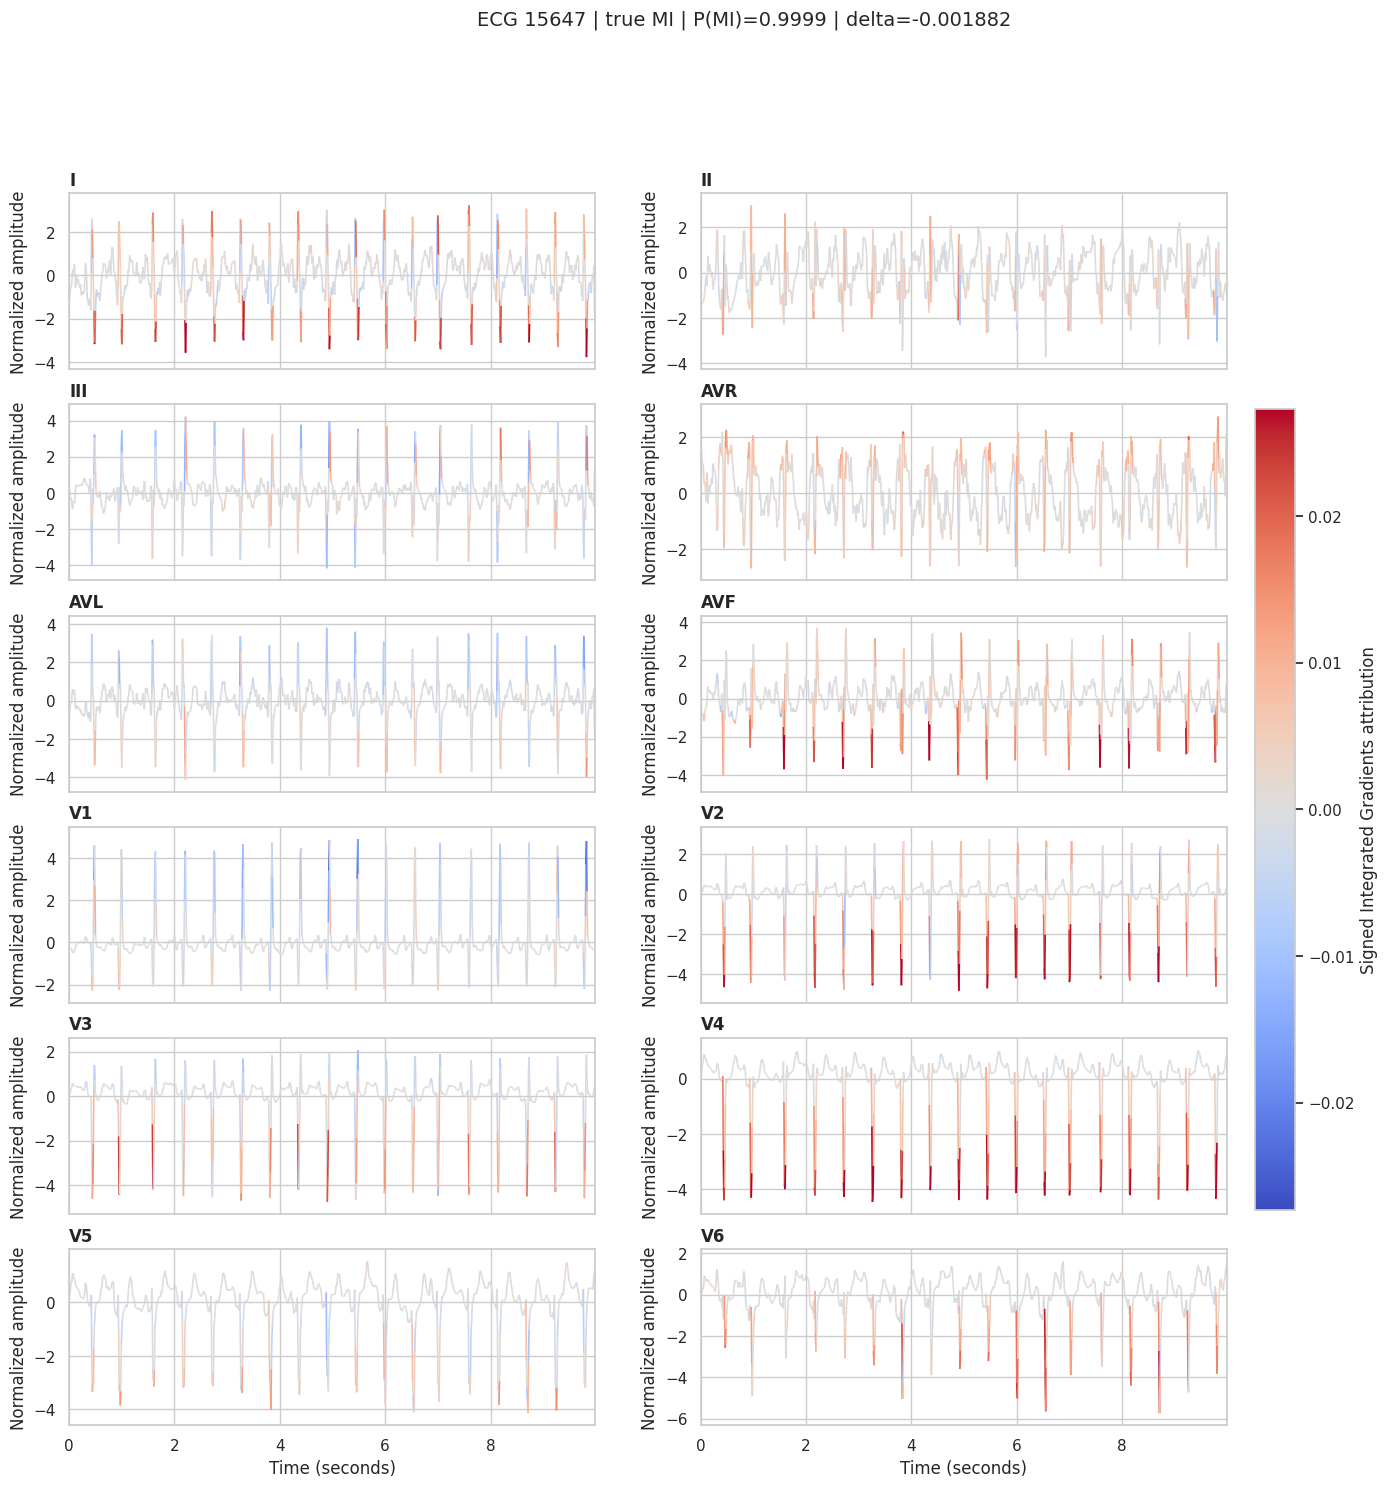

Saved: /content/drive/MyDrive/ptbxl_experiment_5000/integrated_gradients_waveform_attribution.png


In [16]:
sampling_rate = 100
time_axis = np.arange(signal.shape[1]) / sampling_rate
scale = np.percentile(np.abs(attr), 99)
scale = max(scale, 1e-12)

fig, axes = plt.subplots(6, 2, figsize=(18, 16), sharex=True)
axes = axes.ravel()
for lead_idx, ax in enumerate(axes):
    waveform = signal[lead_idx]
    points = np.column_stack([time_axis, waveform]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    segment_attr = 0.5 * (attr[lead_idx, :-1] + attr[lead_idx, 1:])
    collection = LineCollection(segments, cmap='coolwarm', norm=plt.Normalize(-scale, scale))
    collection.set_array(segment_attr)
    collection.set_linewidth(1.2)
    ax.add_collection(collection)
    ax.set_xlim(time_axis[0], time_axis[-1])
    margin = 0.08 * max(np.ptp(waveform), 1e-6)
    ax.set_ylim(waveform.min() - margin, waveform.max() + margin)
    ax.set_title(lead_names[lead_idx], loc='left', fontweight='bold')
    ax.axhline(0, color='0.8', linewidth=0.5)
    if lead_idx >= 10:
        ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Normalized amplitude')

colorbar = fig.colorbar(collection, ax=axes.tolist(), shrink=0.65, pad=0.02)
colorbar.set_label('Signed Integrated Gradients attribution')
fig.suptitle(
    f'ECG {ecg_ids[global_index]} | true MI | P(MI)={probability:.4f} | delta={delta:.6f}',
    fontsize=14,
    y=0.995,
)
waveform_path = OUTPUT_DIR / 'integrated_gradients_waveform_attribution.png'
fig.savefig(waveform_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', waveform_path)


## 10. Interpretation checklist


1. State that the subset is balanced and therefore does not reflect natural prevalence.
2. Report each metric as mean ± SD across seeds, and show the paired seed-level differences.
3. Avoid claiming improvement if differences are small or inconsistent across seeds.
4. Describe Integrated Gradients as explaining model behavior for the selected ECG, not as establishing a clinical diagnosis or causal biomarker.
5. For stronger inference, repeat the experiment on the full official split and consider confidence intervals or a pre-specified statistical analysis.
